# Support Vector Machines
## SVM - Regressie

Deze proef meet de consistentie van vers beton voordat het uithardt, door te kijken hoeveel beton inzakt. Het wordt uitgevoerd om de verwerkbaarheid van pasgemaakt beton te controleren, en daarmee de mate waarin het beton vloeit. Het kan ook gebruikt worden als een indicatie van een onjuist gemengde partij. De zetmaat is het aantal mm dat betonspecie inzakt nadat een standaardkegel met die specie, die op een plat vlak staat, omhoog is getrokken. Het gaat om het aantal mm dat de kegel ingezakt is, dus hoe hoger de zetmaat hoe vloeibaarder de betonspecie (tekening onder)

Onze dataset bestaat uit verschillende eigenschappen van cement en de resulterende zaktestmetrieken in cm. Later wordt het uitgeharde beton getest op zijn druksterkte na 28 dagen.

Invoervariabelen (7) (component kg in één m³ beton):
* Cement
* Slag
* Fly ash
* Water
* SP
* Coarse Aggr.
* Fine Aggr.

Output variabelen (3):
* SLUMP (cm)
* FLOW (cm)
* **28-day Compressive Strength (Mpa)**

Data afkomstig van: https://archive.ics.uci.edu/ml/datasets/Concrete+Slump+Test

*Credit: Yeh, I-Cheng, "Modeling slump flow of concrete using second-order regressions and artificial neural networks," Cement and Concrete Composites, Vol.29, No. 6, 474-480, 2007.*

In [2]:
# Laat illustraties zien die het experimentele opzet verduidelijken
# (een eenvoudige HTML-tabel met plaatjes)
from IPython.core.display import HTML

# Maak een HTML string met de gewenste layout
html = """
<table>
<tr>
<td><img src="Types_of_concrete_slump.jpg" width='200'></td>
<td><img src="betonproef.png" width='200'></td>
<td><img src="betonproef_kegel.png" width='200'></td>
<td><img src="betonproef_voorbeeld.png" width='200'></td>
</tr>
</table>
"""

# Display HTML in de notebook zodat de lezer de testopstelling visueel kan zien
display(HTML(html))

,,,


Kunnen we de druksterkte van het beton voorspellen aan de hand van de input parameters op het ogenblik van het mengen en de resultaten van de zaktest?

In [3]:
# Basisbibliotheken voor numerieke berekeningen, dataframes en visualisatie
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
# Laad de dataset met beton eigenschappen en de slump metingen
df = pd.read_csv('../../../DATA/cement_slump.csv')

In [5]:
# Toon de eerste rijen om de kolommen en voorbeeldwaarden te bekijken
df.head()

,Cement,Slag,Fly ash,Water,SP,Coarse Aggr.,Fine Aggr.,SLUMP(cm),FLOW(cm),Compressive Strength (28-day)(Mpa)
0,273.0,82.0,105.0,210.0,9.0,904.0,680.0,23.0,62.0,34.99
1,163.0,149.0,191.0,180.0,12.0,843.0,746.0,0.0,20.0,41.14
2,162.0,148.0,191.0,179.0,16.0,840.0,743.0,1.0,20.0,41.81
3,162.0,148.0,190.0,179.0,19.0,838.0,741.0,3.0,21.5,42.08
4,154.0,112.0,144.0,220.0,10.0,923.0,658.0,20.0,64.0,26.82


In [6]:
# Bereken correlaties met de doelvariabele (28-day compressive strength)
df.corr()['Compressive Strength (28-day)(Mpa)']

Cement                                0.445656
Slag                                 -0.331522
Fly ash                               0.444380
Water                                -0.254320
SP                                   -0.037909
Coarse Aggr.                         -0.160610
Fine Aggr.                           -0.154532
SLUMP(cm)                            -0.223499
FLOW(cm)                             -0.124189
Compressive Strength (28-day)(Mpa)    1.000000
Name: Compressive Strength (28-day)(Mpa), dtype: float64

<Axes: >

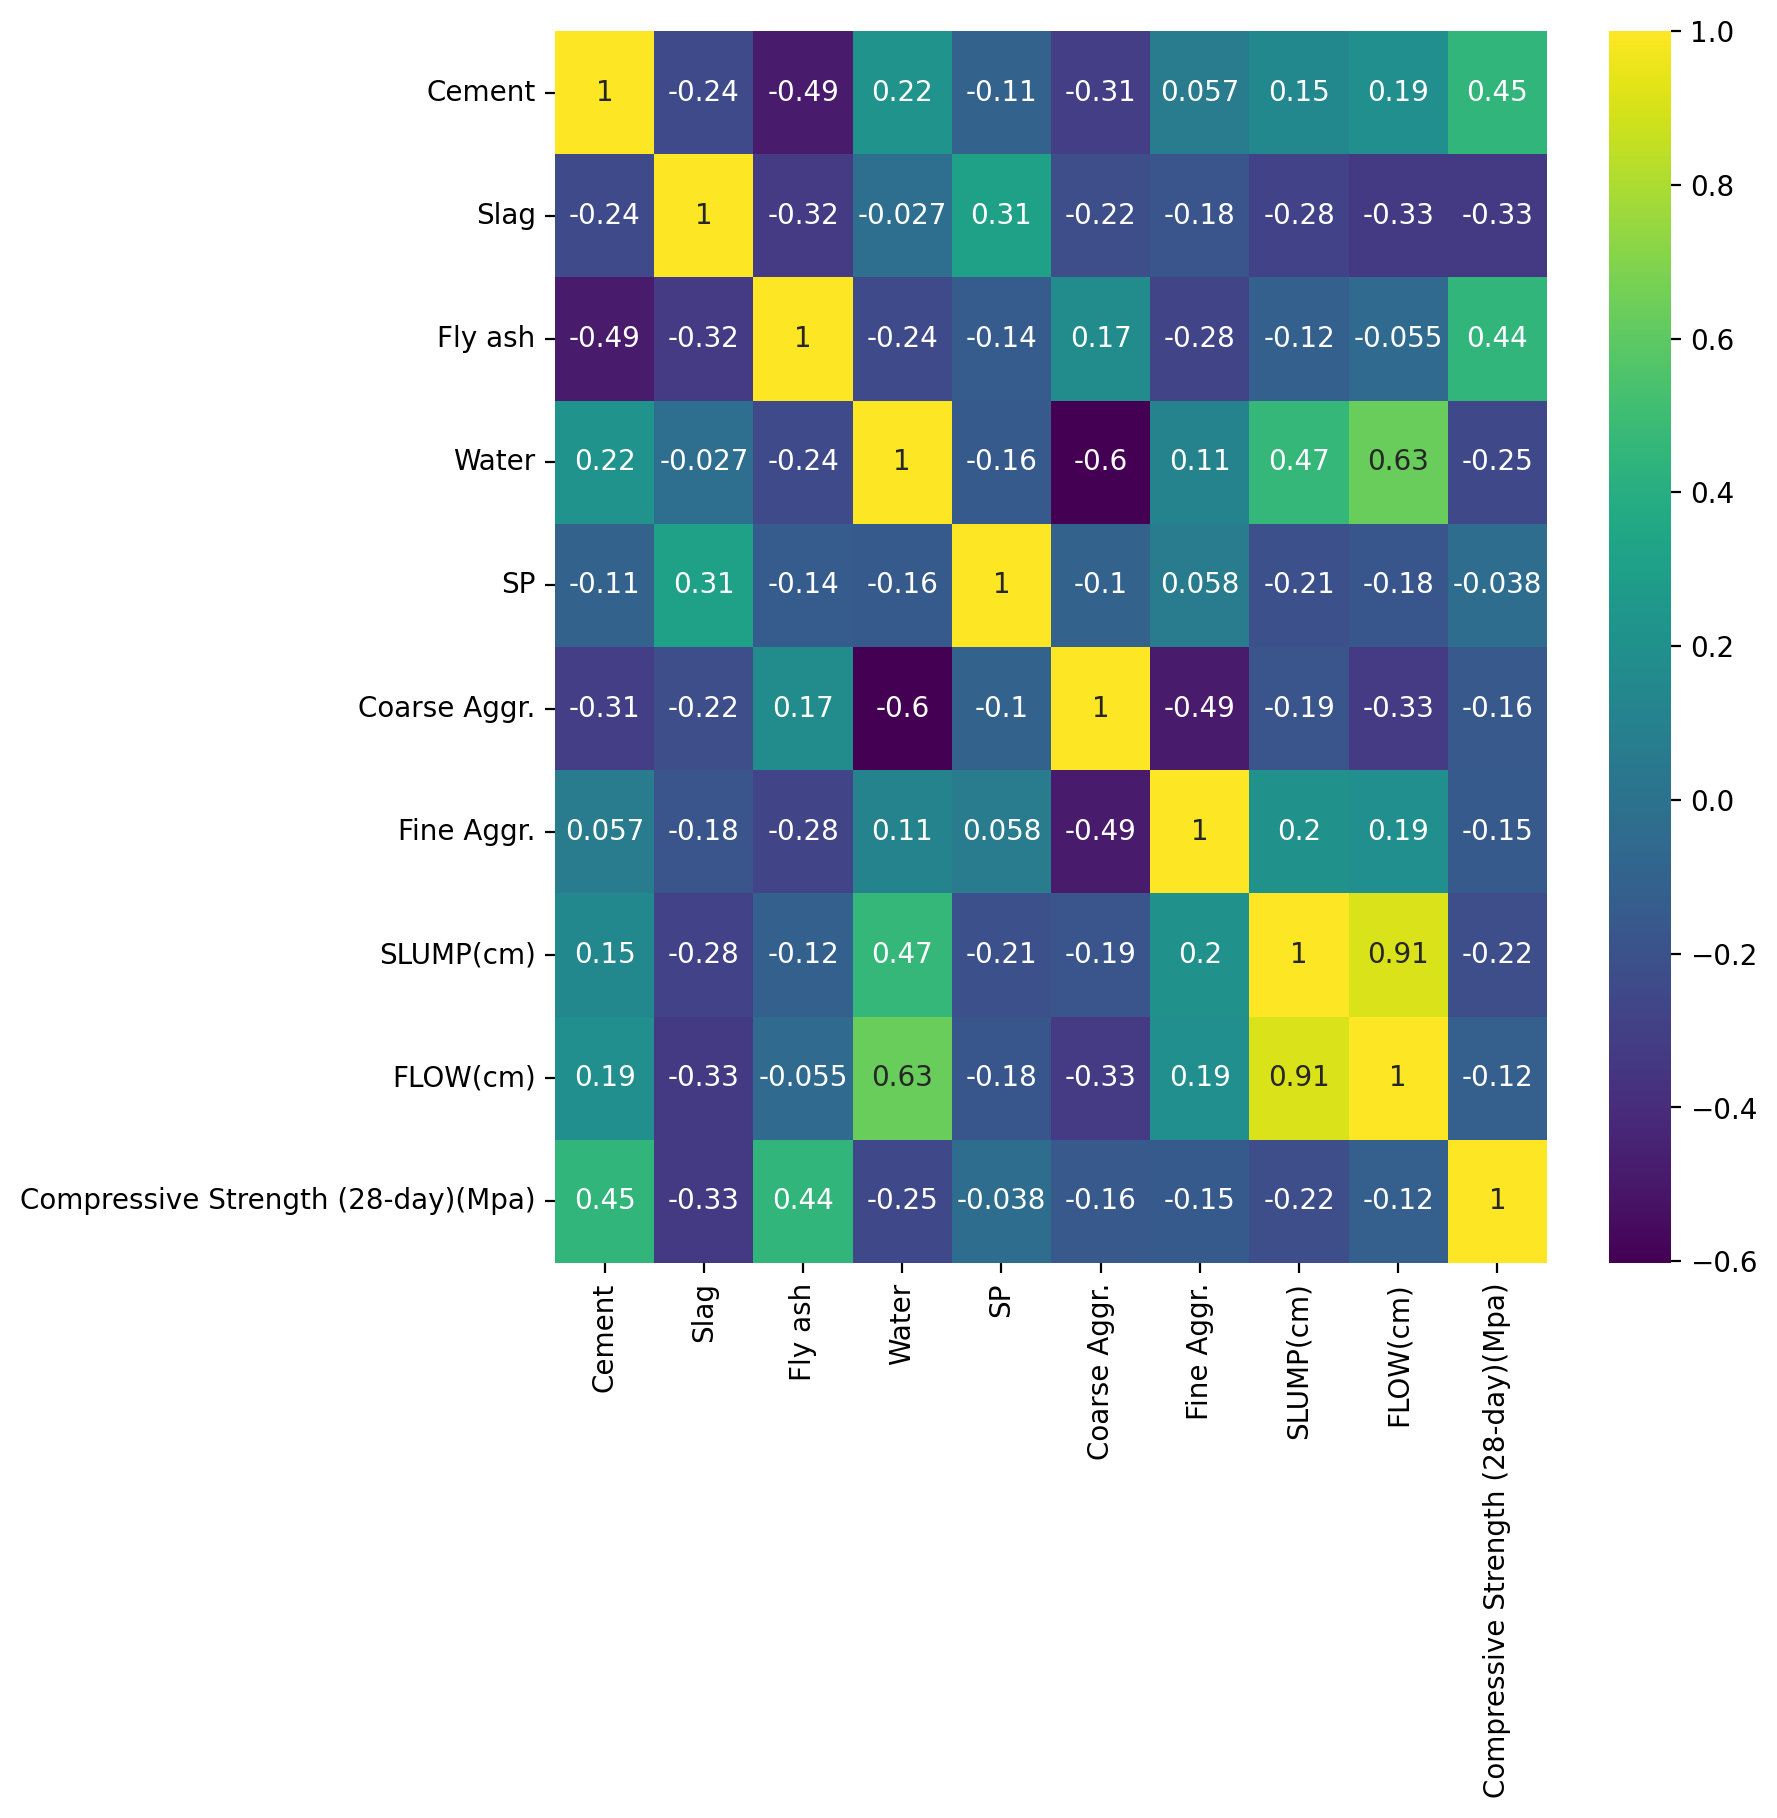

In [7]:
# Visualiseer de volledige correlatiematrix als heatmap
plt.figure(figsize=(8,8), dpi=200)
sns.heatmap(df.corr(),cmap='viridis', annot=True)

In [8]:
# Laat de kolomnamen zien zodat we weten welke features beschikbaar zijn
df.columns

Index(['Cement', 'Slag', 'Fly ash', 'Water', 'SP', 'Coarse Aggr.',
       'Fine Aggr.', 'SLUMP(cm)', 'FLOW(cm)',
       'Compressive Strength (28-day)(Mpa)'],
      dtype='object')

## Train | Test Split

In [9]:
# (nogmaals) controle van de kolomnamen voor de train/test-split
df.columns

Index(['Cement', 'Slag', 'Fly ash', 'Water', 'SP', 'Coarse Aggr.',
       'Fine Aggr.', 'SLUMP(cm)', 'FLOW(cm)',
       'Compressive Strength (28-day)(Mpa)'],
      dtype='object')

In [10]:
# Definieer features X en target y (compressive strength na 28 dagen)
X = df.drop('Compressive Strength (28-day)(Mpa)',axis=1)
y = df['Compressive Strength (28-day)(Mpa)']

In [11]:
# Import voor het opsplitsen van data in train en test sets
from sklearn.model_selection import train_test_split

In [12]:
# Maak een reproduceerbare train/test split (30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=101)

Voor elk algoritme dat naar afmetingen in een feature space kijkt, moeten we scalen.  Bij SVM is dit zeker zo; vaak gaan we zelfs naar hogere dimensies!

In [13]:
# Scale features: SVM's presteren beter als features geschaald zijn
from sklearn.preprocessing import StandardScaler

In [14]:
# Maak een scaler instantie die later op train wordt gefit
scaler = StandardScaler()

In [15]:
# Pas de scaler toe: fit op de train-set en transform op train en test
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

y_test.mean()## Support Vector Machines - Regressie

Er zijn drie verschillende implementaties van Support Vector Regression: SVR, NuSVR en LinearSVR. LinearSVR biedt een snellere implementatie dan SVR, maar houdt alleen rekening met de lineaire kernel, terwijl NuSVR een iets andere formule implementeert dan SVR en LinearSVR. Wanneer je dus geen kernel gebruikt kies je LinearSVR, anders SVR.  NuSVR is een alternatief voor SVR waarbij je meer controle hebt over bijvoorbeeld het aantal Support Vectors.  De parameter nu in NuSVR geeft een benadering van de fractie van de support vectors in verhouding tot het totale aantal vectoren.  In situaties waar rekenbronnen beperkt zijn, kan het beperken van het aantal support vectors helpen om de voorspellingssnelheid te verhogen, omdat de complexiteit van een SVM-model grotendeels afhankelijk is van het aantal support vectors.  In dezelfde zin kan het beperken van het aantal support vectors overfitting verminderen.  

Zie [Implementatie details](https://scikit-learn.org/stable/modules/svm.html#svm-implementation-details) voor meer informatie.

In [16]:
# Importeer SVR-implementaties: SVR voor kernels, LinearSVR voor lineair
from sklearn.svm import SVR,LinearSVR

We kunnen een kernel kiezen (default 'rbf), een degree (polynomial), een gamma, een C (default 1) - het instellen van C: C is standaard 1 en dat is een redelijke standaardkeuze. Als je veel grillige observaties hebt, moet je C verlagen: een lagere C komt overeen met meer regularisatie.

LinearSVC en LinearSVR zijn minder gevoelig voor C wanneer deze groot wordt, en de voorspellingsresultaten stoppen met verbeteren na een bepaalde drempel. Ondertussen zullen grotere C-waarden meer tijd in beslag nemen om te trainen, soms tot wel 10 keer langer.

Epsilon: https://stats.stackexchange.com/questions/259018/meaning-of-epsilon-in-svm-regression

Epsilon is een parameter die wordt gebruikt bij het trainen van een SVR model. Epsilon bepaalt hoe tolerant het model is.  Deze tolerantie zorgt voor meer bias, en dus een beter generaliserend model.  Ook epsilon wordt via Grid search bepaald. 

Epsilon (ε) is een parameter die de breedte van de ε-band rond de regressielijn definieert. Binnen deze band worden fouten niet bestraft, wat betekent dat alle punten binnen deze marge als correct worden beschouwd door het model, ongeacht of ze precies op de regressielijn liggen. Dit concept is cruciaal in SVR omdat het helpt bij het bepalen van de mate van tolerantie voor fouten tegenover de voorspellingen van het model.

Het belangrijkste doel van epsilon is om overfitting te verminderen en de generalisatie van het model te verbeteren. Door de epsilon-waarde aan te passen, kun je beïnvloeden hoe gevoelig het model is voor trainingssamples die dicht bij de werkelijke regressielijn liggen:

Een **kleine** epsilon-waarde leidt tot een **smaller gebied rond de regressielijn**, wat betekent dat meer datapunten als fouten zullen worden beschouwd en dus de modelcomplexiteit kan toenemen omdat het meer gevoelig is voor de training data.  

Een **grote** epsilon-waarde creëert een **breder gebied rond de regressielijn**, waardoor minder datapunten als fouten worden beschouwd. Dit kan helpen om overfitting te verminderen, omdat het model minder gevoelig is voor kleine fluctuaties in de trainingsdata.  

De keuze van epsilon is dus een belangrijke afweging in SVR-modellen, omdat het een directe impact heeft op de prestaties en de complexiteit van het model. Het vinden van de optimale epsilon-waarde is vaak een kwestie van experimentatie en validatie om de beste balans tussen bias en variantie, specifiek voor de gegeven dataset, te bereiken.

<img src="epsilon.png" width='200'></td>

In [17]:
# Basis SVR-model met standaard hyperparameters (voor vergelijking)
base_model = SVR() # basis model!

In [18]:
# Train het basis SVR-model op de geschaalde traindata
base_model.fit(scaled_X_train,y_train)

SVR()

In [19]:
# Maak voorspellingen op de testset met het getrainde basis-model
base_preds = base_model.predict(scaled_X_test)

## Evaluatie

In [20]:
# Importeer evaluatiematen om modelprestaties te kwantificeren
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [21]:
# Bereken Mean Absolute Error voor het basis-model
mean_absolute_error(y_test,base_preds)

5.236902091259178

In [22]:
# Bereken Root Mean Squared Error (RMSE) voor het basis-model
np.sqrt(mean_squared_error(y_test,base_preds))

6.695914838327133

In [23]:
# Toon het gemiddelde van y_test als referentiewaarde
y_test.mean()

36.26870967741935

## Grid Search om het model mogelijk te verbeteren

In [24]:
# Parametergrid voor GridSearch: zoek naar goede C, kernel, gamma, degree en epsilon
param_grid = {'C':[0.001,0.01,0.1,0.5,1],
             'kernel':['linear','rbf','poly'],
              'gamma':['scale','auto'],
              'degree':[2,3,4],
              'epsilon':[0,0.01,0.1,0.5,1,2]}

In [25]:
# GridSearchCV om systematisch hyperparameters te doorzoeken
from sklearn.model_selection import GridSearchCV

In [26]:
# Maak een SVR instantie en een GridSearchCV wrapper met de opgegeven grid
svr = SVR()
grid = GridSearchCV(svr,param_grid=param_grid)

In [27]:
# Voer de grid search uit op de geschaalde trainingsdata (dit kan even duren)
grid.fit(scaled_X_train,y_train)

GridSearchCV(estimator=SVR(),
             param_grid={'C': [0.001, 0.01, 0.1, 0.5, 1], 'degree': [2, 3, 4],
                         'epsilon': [0, 0.01, 0.1, 0.5, 1, 2],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']})

In [28]:
# Toon de beste gevonden hyperparameters
grid.best_params_

{'C': 1, 'degree': 2, 'epsilon': 2, 'gamma': 'scale', 'kernel': 'linear'}

In [29]:
# Voorspel op de testset met het beste model uit de grid search
grid_preds = grid.predict(scaled_X_test)

In [30]:
# Evalueer Mean Absolute Error voor het getunede model
mean_absolute_error(y_test,grid_preds)

2.512801221076176

In [31]:
# Bereken RMSE voor het getunede model
np.sqrt(mean_squared_error(y_test,grid_preds))

3.178210305119839

Dit is een grote verbetering!

In [33]:
# Random Forest Regressor met eenvoudige hyperparameter tuning
# We gebruiken een pipeline met (optioneel) scaling en GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import make_pipeline

# Bouw pipeline (scalen is niet strikt noodzakelijk voor bomen, maar houdt consistentie)
rf_pipeline = make_pipeline(StandardScaler(), RandomForestRegressor(random_state=42))

# Eenvoudige parametergrid: aantal bomen, maximale diepte en minimale splitsing
rf_param_grid = {
    'randomforestregressor__n_estimators': [25, 50, 100, 150, 200],
    'randomforestregressor__max_depth': [None, 2, 5, 10],
    'randomforestregressor__min_samples_split': [2, 5]
}

# Grid search met 5-fold CV en neg_mean_squared_error als score
rf_grid = GridSearchCV(rf_pipeline, rf_param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

# Fit op de geschaalde trainingdata (scaler zit in de pipeline)
rf_grid.fit(X_train, y_train)

print('RandomForest best params:', rf_grid.best_params_)
print('RandomForest best CV score (neg MSE):', rf_grid.best_score_)

# Evaluatie op de testset
rf_best = rf_grid.best_estimator_
rf_preds = rf_best.predict(X_test)
from sklearn.metrics import mean_absolute_error, mean_squared_error
print('RandomForest MAE:', mean_absolute_error(y_test, rf_preds))
print('RandomForest RMSE:', np.sqrt(mean_squared_error(y_test, rf_preds)))

# (Optioneel) Toon feature importances als referentie
try:
    importances = rf_best.named_steps['randomforestregressor'].feature_importances_
    print('Feature importances:', importances)
except Exception:
    pass


Fitting 5 folds for each of 40 candidates, totalling 200 fits
RandomForest best params: {'randomforestregressor__max_depth': None, 'randomforestregressor__min_samples_split': 2, 'randomforestregressor__n_estimators': 100}
RandomForest best CV score (neg MSE): -15.628037010142867
RandomForest MAE: 3.208606451612898
RandomForest RMSE: 4.0656446069076635
Feature importances: [0.38441914 0.09464647 0.31754947 0.0548739  0.02079545 0.02323651
 0.04489449 0.03623607 0.02334851]


In [34]:
# Eenvoudige lineaire regressie als interpreteerbaar referentiemodel
from sklearn.linear_model import LinearRegression
# We gebruiken een pipeline zodat scaling consistent wordt toegepast
lin_pipeline = make_pipeline(StandardScaler(), LinearRegression())
# Fit op de trainingsdata
lin_pipeline.fit(X_train, y_train)
# Voorspel en evalueer op de testset
lin_preds = lin_pipeline.predict(X_test)
print('LinearRegression MAE:', mean_absolute_error(y_test, lin_preds))
print('LinearRegression RMSE:', np.sqrt(mean_squared_error(y_test, lin_preds)))
# Toon intercept en coëfficiënten (van de lineaire stap)
coef = lin_pipeline.named_steps['linearregression'].coef_
intercept = lin_pipeline.named_steps['linearregression'].intercept_
print('Intercept:', intercept)
print('Coefficients:', coef)
# Vergelijk kort met eventuele eerdere modelvoorspellingen indien beschikbaar
try:
    print('SVR MAE (indien beschikbaar):', mean_absolute_error(y_test, grid_preds))
except Exception:
    pass
try:
    print('RandomForest MAE (indien beschikbaar):', mean_absolute_error(y_test, rf_preds))
except Exception:
    pass


LinearRegression MAE: 2.305110540518305
LinearRegression RMSE: 2.860730457938178
Intercept: 35.93972222222222
Coefficients: [ 4.74686383e+00 -1.59603568e+00  4.27289463e+00 -3.51003342e+00
 -1.07837026e-05 -3.97955808e+00 -2.20767067e+00 -1.77445961e+00
  1.16528703e+00]
SVR MAE (indien beschikbaar): 2.512801221076176
RandomForest MAE (indien beschikbaar): 3.208606451612898


In [35]:
# Coefficients (Linear regression — met StandardScaler in pipeline)
coefs = lin_pipeline.named_steps['linearregression'].coef_
feat_names = X.columns
print('Linear coef (abs sorted):')
print(sorted(zip(feat_names, coefs), key=lambda x: abs(x[1]), reverse=True))

# Random Forest feature_importances_
rf_imp = rf_best.named_steps['randomforestregressor'].feature_importances_
print('RandomForest importances (sorted):')
print(sorted(zip(feat_names, rf_imp), key=lambda x: x[1], reverse=True))

# Permutation importance (robuuste, comparable measure for both)
from sklearn.inspection import permutation_importance
r_lin = permutation_importance(lin_pipeline, X_test, y_test, n_repeats=30, random_state=0, n_jobs=-1)
r_rf  = permutation_importance(rf_best,   X_test, y_test, n_repeats=30, random_state=0, n_jobs=-1)

print('Permutation importance (linear):', sorted(zip(feat_names, r_lin.importances_mean), key=lambda x: x[1], reverse=True))
print('Permutation importance (rf):    ', sorted(zip(feat_names, r_rf.importances_mean),  key=lambda x: x[1], reverse=True))

Linear coef (abs sorted):
[('Cement', 4.746863826765766), ('Fly ash', 4.2728946326423625), ('Coarse Aggr.', -3.9795580805257784), ('Water', -3.51003341880259), ('Fine Aggr.', -2.207670665641835), ('SLUMP(cm)', -1.7744596113465037), ('Slag', -1.5960356782690255), ('FLOW(cm)', 1.1652870265066775), ('SP', -1.0783702630154664e-05)]
RandomForest importances (sorted):
[('Cement', 0.3844191383842082), ('Fly ash', 0.31754946668866085), ('Slag', 0.0946464749028221), ('Water', 0.0548738970921979), ('Fine Aggr.', 0.0448944865085236), ('SLUMP(cm)', 0.03623606830022875), ('FLOW(cm)', 0.02334850979699519), ('Coarse Aggr.', 0.023236508016133323), ('SP', 0.02079545031023009)]
Permutation importance (linear): [('Cement', 0.8969107390032452), ('Fly ash', 0.6987088529625168), ('Water', 0.6352696686845046), ('Coarse Aggr.', 0.42585135757649123), ('SLUMP(cm)', 0.15284461198971705), ('Fine Aggr.', 0.0508550514361181), ('Slag', 0.05048611520713906), ('SP', -4.58391870391169e-07), ('FLOW(cm)', -0.002485518325

In [38]:
# display feature importance in bar charts side by side for linear and RF
print('Feature importance comparison (linear vs RF):')
for feat in feat_names:
    lin_imp = next((imp for f, imp in zip(feat_names, r_lin.importances_mean) if f == feat), None)
    rf_imp = next((imp for f, imp in zip(feat_names, r_rf.importances_mean) if f == feat), None)
    print(f'{feat}: Linear={lin_imp:.4f}, RF={rf_imp:.4f}')




Feature importance comparison (linear vs RF):
Cement: Linear=0.8969, RF=0.9128
Slag: Linear=0.0505, RF=0.0129
Fly ash: Linear=0.6987, RF=0.8691
Water: Linear=0.6353, RF=0.0680
SP: Linear=-0.0000, RF=0.0129
Coarse Aggr.: Linear=0.4259, RF=0.0017
Fine Aggr.: Linear=0.0509, RF=0.0016
SLUMP(cm): Linear=0.1528, RF=0.0163
FLOW(cm): Linear=-0.0025, RF=0.0136


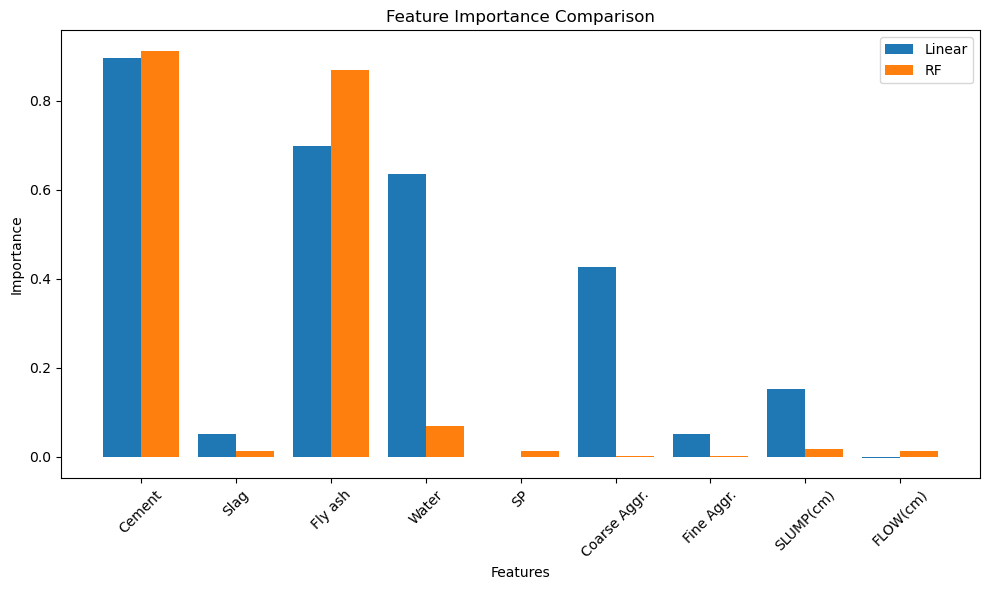

In [39]:
# display in bar charts
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
x = range(len(feat_names))
plt.bar([i - 0.2 for i in x], [next((imp for f, imp in zip(feat_names, r_lin.importances_mean) if f == feat), None) for feat in feat_names], width=0.4, label='Linear')
plt.bar([i + 0.2 for i in x], [next((imp for f, imp in zip(feat_names, r_rf.importances_mean) if f == feat), None) for feat in feat_names], width=0.4, label='RF')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Feature Importance Comparison')
plt.xticks(x, feat_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()